In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl


import warnings
warnings.filterwarnings("ignore")


plt.style.use('ggplot')
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

rc = {'figure.figsize':(10,5),
'axes.facecolor':'white',
'axes.grid' : False,
'grid.color': '.8',
'font.family':'Arial',
'font.size' : 12}
plt.rcParams.update(rc)


In [2]:
Fluxes = pd.read_csv(r"../results/pFBA_fluxes.csv", index_col=0)
Fluxes

,modelGb1_bin16,modelGb1_bin17,modelGb1_bin20,modelGb1_bin43,modelGb2_bin20,modelGb2_bin21,modelGb4_bin17,modelGb7_bin10,modelGb7_bin15,modelGb7_bin28,modelGb7_bin5,modelGb7_bin9,modelGb8_bin5,modelGb8_bin50
3PEPTabcpp,0.000000,NaN,4.858109,0.000000,3.383700e+00,2.505943,0.000000,2.181775,NaN,1.725909,4.486465,2.343056,3.369515e+00,1.664194e+00
3PGt6,996.980331,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN
3SALATAi,0.000000,NaN,NaN,NaN,0.000000e+00,0.000000,NaN,NaN,NaN,NaN,0.000000,NaN,0.000000e+00,NaN
4HPRO_LT_Et,0.000000,NaN,NaN,NaN,0.000000e+00,29.024605,NaN,NaN,NaN,NaN,0.000000,NaN,-3.890000e-16,-5.290000e-14
4PEPTabcpp,2.127397,NaN,NaN,0.981851,-5.250000e-16,NaN,1.510886,0.000000,3.209126,0.000000,0.000000,NaN,NaN,0.000000e+00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
EX_ura_e,0.000000,3.050550,NaN,-2.266064,5.882021e+00,NaN,NaN,-99.742827,3.209126,NaN,NaN,NaN,NaN,NaN
EX_val__L_e,-9.002335,-12.908768,-20.557671,0.000000,0.000000e+00,0.000000,-6.393497,-9.232441,0.000000,0.000000,-18.985015,0.000000,NaN,-5.935761e+00
EX_zn2_e,-0.007254,-0.010402,-0.016566,-0.003348,-1.153842e-02,-0.008545,-0.005152,-0.007440,-0.010943,-0.005885,-0.015299,-0.007990,-1.149005e-02,-5.674902e-03
Growth,21.273968,30.505498,48.581089,9.818513,3.383700e+01,25.059427,15.108864,21.817746,32.091264,17.259089,44.864650,23.430560,3.369515e+01,1.664194e+01


In [3]:
Ex_rxn_flux = Fluxes[Fluxes.index.str.contains("EX_")].dropna().T
Ex_rxn_flux.shape

(14, 18)

In [4]:
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler
scalar = StandardScaler(with_mean=False)

selector = VarianceThreshold(0.0)
selector.fit_transform(Ex_rxn_flux)
mask = selector.get_support()
selected_cols = Ex_rxn_flux.columns[mask]
Ex_rxn_flux = Ex_rxn_flux.loc[:, selected_cols]
Ex_rxn_flux

,EX_acald_e,EX_ca2_e,EX_cgly_e,EX_cl_e,EX_co2_e,EX_cobalt2_e,EX_fe3_e,EX_h2o_e,EX_h2s_e,EX_h_e,EX_k_e,EX_mg2_e,EX_mn2_e,EX_nh4_e,EX_o2_e,EX_zn2_e
modelGb1_bin16,-1.843347e+01,-0.110731,-4.620000e-29,-0.110731,1000.000000,-0.002127,0.000000,867.206991,-6.605471,8.284051,-4.152530,-0.184552,-0.014700,-7.068329,-492.052051,-0.007254
modelGb1_bin17,0.000000e+00,-0.158781,-2.634912e+00,-0.158781,1000.000000,-0.003051,-0.238187,1000.000000,-0.132333,-513.097155,-5.954460,-0.264635,-0.021079,-66.018992,-688.704221,-0.010402
modelGb1_bin20,3.605276e+00,-0.252865,-9.966103e+01,-0.252865,1000.000000,-0.004858,-0.705543,-1000.000000,677.815893,-1000.000000,-9.482689,-0.421441,-0.033570,1000.000000,-461.762478,-0.016566
modelGb1_bin43,2.806480e+02,-0.051105,0.000000e+00,-0.051105,1000.000000,-0.000982,0.000000,0.000000,6.524804,-4.876286,-1.916505,-0.085176,-0.006785,283.759895,-595.241383,-0.003348
modelGb2_bin20,-2.368113e+01,-0.176122,0.000000e+00,-0.176122,1000.000000,-0.003384,0.000000,642.758559,638.874135,460.767067,-6.604746,-0.293536,-0.023381,0.000000,-282.008750,-0.011538
modelGb2_bin21,-7.250000e-15,-0.130434,0.000000e+00,-0.130434,1000.000000,-0.002506,-0.195664,173.745086,2.294942,-444.091455,-4.891425,-0.217391,-0.017316,833.739989,-13.726990,-0.008545
modelGb4_bin17,9.771589e+00,-0.078642,0.000000e+00,-0.078642,1000.000000,-0.001511,-0.117970,73.040911,0.000000,-5.783809,-2.949144,-0.131069,-0.010440,999.151811,-819.170817,-0.005152
modelGb7_bin10,1.000000e+03,-0.113561,0.000000e+00,-0.113561,1000.000000,-0.002182,-0.170353,-1000.000000,-1.995887,-418.201046,-4.258671,-0.189269,-0.015076,971.108075,-543.297028,-0.007440
modelGb7_bin15,3.142540e+01,-0.167035,-2.938918e+00,-0.167035,827.444739,-0.003209,321.607292,110.109745,208.871915,-425.056715,-6.263990,-0.278392,-0.022175,1000.000000,-1000.000000,-0.010943
modelGb7_bin28,-7.303391e+00,-0.089834,0.000000e+00,-0.089834,1000.000000,-0.001726,-0.134759,993.774432,-0.074870,0.000000,-3.368853,-0.149723,-0.011926,294.928974,-438.039392,-0.005885


In [5]:
Ex_rxn_flux = pd.DataFrame(scalar.fit_transform(Ex_rxn_flux), index=Ex_rxn_flux.index, columns=Ex_rxn_flux.columns)
Ex_rxn_flux

,EX_acald_e,EX_ca2_e,EX_cgly_e,EX_cl_e,EX_co2_e,EX_cobalt2_e,EX_fe3_e,EX_h2o_e,EX_h2s_e,EX_h_e,EX_k_e,EX_mg2_e,EX_mn2_e,EX_nh4_e,EX_o2_e,EX_zn2_e
modelGb1_bin16,-4.827707e-02,-1.972541,-1.806477e-30,-1.972541,4.019945,-1.972541,0.000000,1.342438,-0.028715,0.022613,-1.972541,-1.972541,-1.972541,-0.016101,-1.888932,-1.972541
modelGb1_bin17,0.000000e+00,-2.828497,-1.030283e-01,-2.828497,4.019945,-2.828497,-0.002874,1.548002,-0.000575,-1.400580,-2.828497,-2.828497,-2.828497,-0.150381,-2.643858,-2.828497
modelGb1_bin20,9.442181e-03,-4.504482,-3.896869e+00,-4.504482,4.019945,-4.504482,-0.008513,-1.548002,2.946521,-2.729658,-4.504482,-4.504482,-4.504482,2.277845,-1.772654,-4.504482
modelGb1_bin43,7.350144e-01,-0.910381,0.000000e+00,-0.910381,4.019945,-0.910381,0.000000,0.000000,0.028364,-0.013311,-0.910381,-0.910381,-0.910381,0.646361,-2.285064,-0.910381
modelGb2_bin20,-6.202065e-02,-3.137397,0.000000e+00,-3.137397,4.019945,-3.137397,0.000000,0.994992,2.777238,1.257737,-3.137397,-3.137397,-3.137397,0.000000,-1.082600,-3.137397
modelGb2_bin21,-1.898768e-17,-2.323532,0.000000e+00,-2.323532,4.019945,-2.323533,-0.002361,0.268958,0.009976,-1.212218,-2.323532,-2.323532,-2.323532,1.899131,-0.052696,-2.323532
modelGb4_bin17,2.559170e-02,-1.400907,0.000000e+00,-1.400907,4.019945,-1.400907,-0.001423,0.113067,0.000000,-0.015788,-1.400907,-1.400907,-1.400907,2.275913,-3.144704,-1.400907
modelGb7_bin10,2.618990e+00,-2.022961,0.000000e+00,-2.022961,4.019945,-2.022961,-0.002055,-1.548002,-0.008676,-1.141546,-2.022961,-2.022961,-2.022961,2.212034,-2.085656,-2.022961
modelGb7_bin15,8.230282e-02,-2.975531,-1.149153e-01,-2.975531,3.326282,-2.975530,3.880395,0.170450,0.907983,-1.160260,-2.975531,-2.975531,-2.975531,2.277845,-3.838887,-2.975531
modelGb7_bin28,-1.912751e-02,-1.600278,0.000000e+00,-1.600278,4.019945,-1.600278,-0.001626,1.538365,-0.000325,0.000000,-1.600278,-1.600278,-1.600278,0.671803,-1.681584,-1.600278


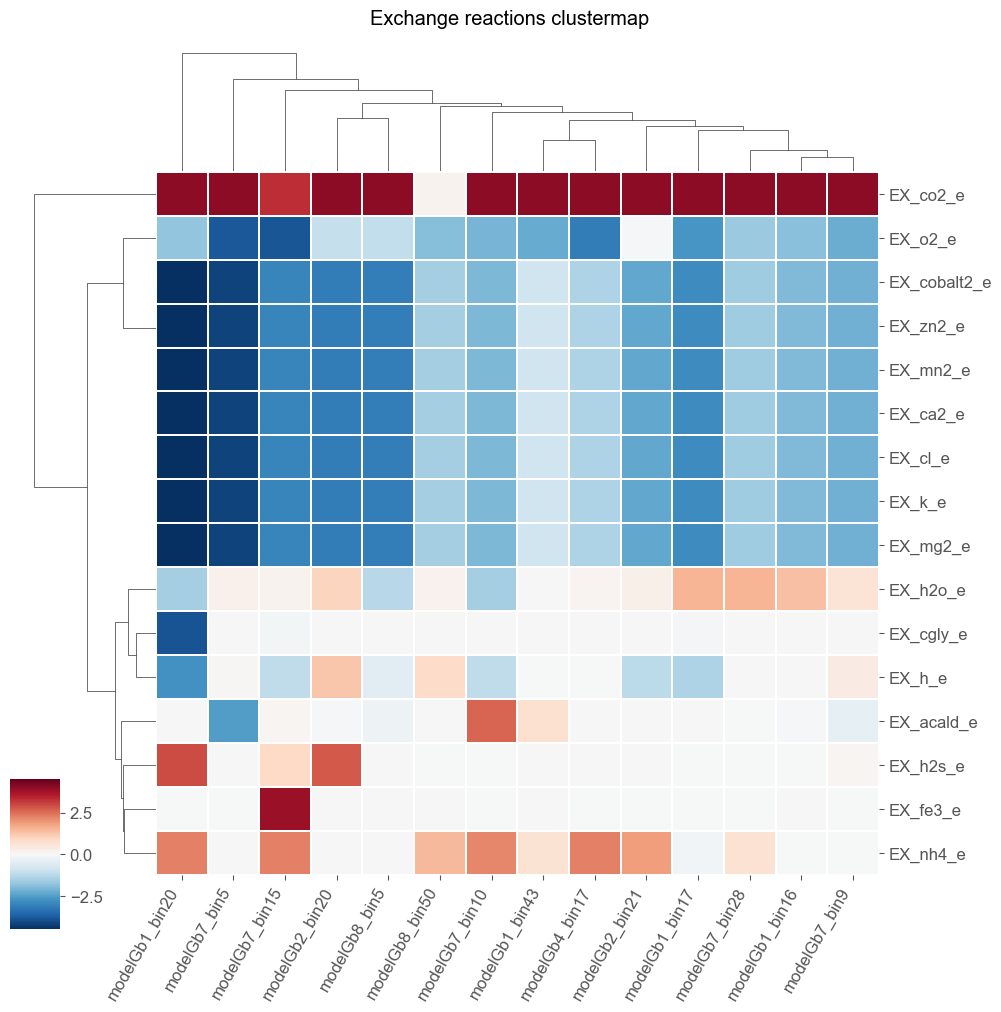

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import numpy as np

vmax = np.nanmax(np.abs(Ex_rxn_flux.values))
vmin = -vmax

g = sns.clustermap(
    Ex_rxn_flux.T,
    figsize=(10, 10),
    cmap="RdBu_r",
    norm=TwoSlopeNorm(vcenter=0, vmin=vmin, vmax=vmax),
    dendrogram_ratio=(0.15, 0.15),
    cbar_pos=(0.0, 0.1, 0.05, 0.15),
    linewidths=0.1,
    linecolor="white"
)

plt.setp(g.ax_heatmap.get_xticklabels(), rotation=60, ha="right")
plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0)

g.fig.suptitle("Exchange reactions clustermap", y=1.02)
plt.show()

<Figure size 1000x1000 with 0 Axes>

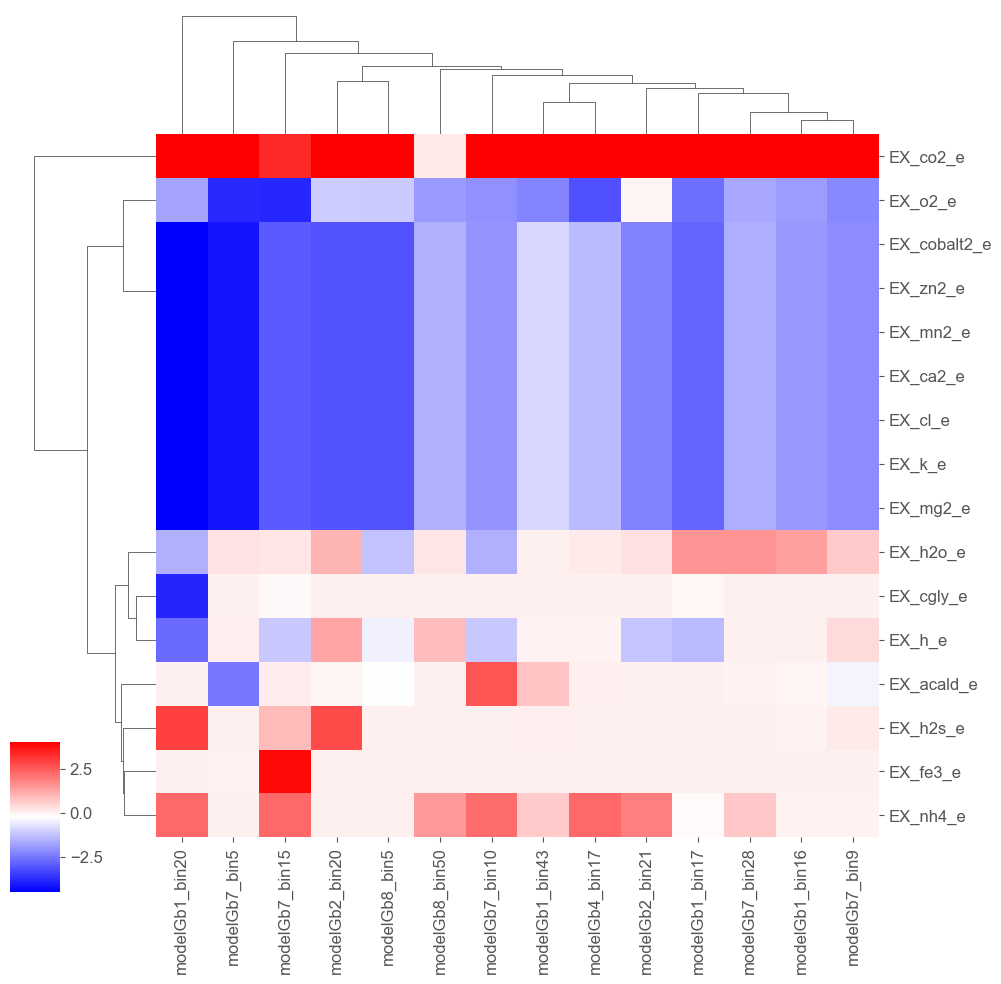

In [7]:
plt.figure(figsize=(10,10))
sns.clustermap(Ex_rxn_flux.T, 
               cmap='bwr',    
               dendrogram_ratio=(0.15, 0.15),
               cbar_pos=(0.0, 0.1, 0.05, 0.15)
               )
plt.show()

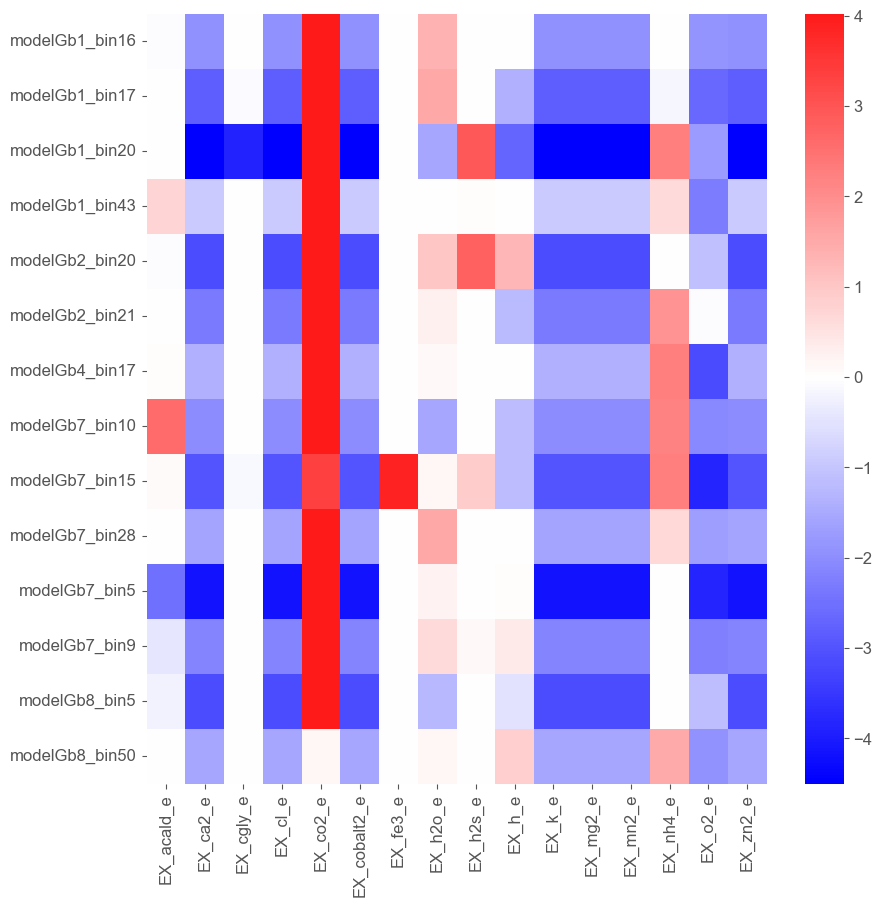

In [8]:
plt.figure(figsize=(10,10))
sns.heatmap(Ex_rxn_flux, center=0, cmap='bwr')
plt.show()

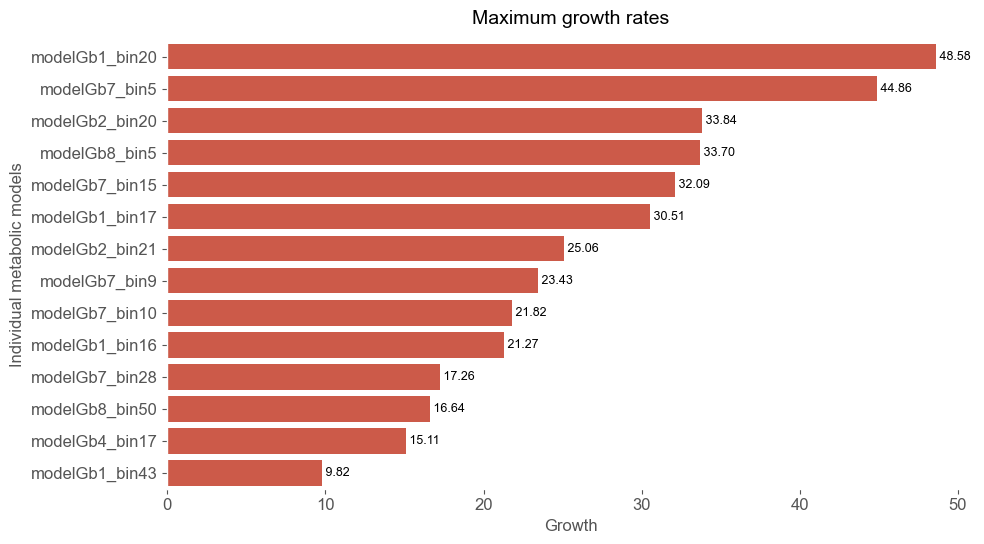

In [10]:
growth_series = Fluxes.loc['Growth']
growth_series = pd.to_numeric(growth_series, errors="coerce").dropna()
growth_series = growth_series.sort_values(ascending=False)

plt.figure(figsize=(10, max(4, 0.4 * len(growth_series))))  # adaptive height
# sns.set(style="whitegrid")
ax = sns.barplot(
    x=growth_series.values,
    y=growth_series.index,
    # palette="Set2"
)

ax.set_xlabel("Growth", fontsize=12)
ax.set_ylabel("Individual metabolic models", fontsize=12)
ax.set_title("Maximum growth rates", fontsize=14, pad=12)

for i, v in enumerate(growth_series.values):
    ax.text(v, i, f" {v:.2f}", va="center", ha="left", fontsize=9)

plt.tight_layout()
plt.show()